# Fully Connected Neural Network


### Import Packages


In [1]:
import os
import time
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.optimizers import Adam
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, UpSampling1D
from tensorflow.keras.utils import Sequence
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# from tensorflow.keras.callbacks import Callback
from scipy.stats import skew, kurtosis

## Check If GPU Enabled

Latest functioning version set as of October 6, 2024 according to https://www.tensorflow.org/install/source_windows is

-   Python 3.10.11
-   Tensorflow 2.10
-   CUDA Toolkit 11.2
-   CUDNN 8.1


In [2]:
# tf.debugging.set_log_device_placement(True) # For Verbose Output
print("Version: ", tf.__version__)
print("Num GPUs Available: ", tf.config.list_physical_devices("GPU"))
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print("TensorFlow is using GPU")
    for gpu in gpus:
        print(gpu.name)
else:
    print("TensorFlow is not using GPU")

Version:  2.10.0
Num GPUs Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow is using GPU
/physical_device:GPU:0


## Metric Evaluation


In [3]:
# class MetricsCallback(Callback):
#     def __init__(self, test_data, y_true):
#         self.y_true = y_true
#         self.test_data = test_data

#     def on_epoch_end(self, epoch, logs=None):
#         y_pred = self.model.predict(self.test_data)
#         y_pred = tf.argmax(y_pred, axis=1)

#         report_dictionary = classification_report(self.y_true, y_pred, output_dict=True)
#         print(classification_report(self.y_true, y_pred, output_dict=False))

## Binary Pick Mars or Moon


In [4]:
moon = True
train = False

if moon and not train:
    test_set = [
        "S12_GradeB/",
        "S15_GradeA/",
        "S15_GradeB/",
        "S16_GradeA/",
        "S16_GradeB/",
    ][3]

## Hyperparameters


In [5]:
windows_size = 128
batch_size = 500  # 20
label_smoothing = 0.1
n_epochs = 30
dropout = 0.5
learning_rate = 0.01

if moon:
    freq = 6.625
else:
    freq = 20

# kernel_size = [7, 1]
# pool_size = [4, 1]
# decay_step = 1e9
# decay_rate = 0.9
# drop_rate = 0

## Pick Datasets to Train or Test


In [6]:
if train:
    if moon:
        lunar_train_dir = r"../../data/lunar/training/data/S12_GradeA"
        num_of_events = len(
            [file for file in os.listdir(lunar_train_dir) if file.endswith(".csv")]
        )
        print("Lunar Number of Events: ", num_of_events)
        event = [i for i in range(2)]  # num_of_events

    else:
        mars_train_dir = r"../../data/mars/training/data/"
        num_of_events = len(
            [file for file in os.listdir(mars_train_dir) if file.endswith(".csv")]
        )
        print("Mars Number of Events: ", num_of_events)
        event = [i for i in range(num_of_events)]  # num_of_events

else:
    if moon:
        lunar_test_dir = r"../../data/lunar/test/data/" + test_set
        num_of_events = len(
            [file for file in os.listdir(lunar_test_dir) if file.endswith(".csv")]
        )
        print("Lunar Number of Events: ", num_of_events)
        event = [i for i in range(num_of_events)]  # num_of_events

    else:
        mars_test_dir = r"../../data/mars/test/data/"
        num_of_events = len(
            [file for file in os.listdir(mars_test_dir) if file.endswith(".csv")]
        )
        print("Mars Number of Events: ", num_of_events)
        event = [i for i in range(num_of_events)]  # num_of_events

Lunar Number of Events:  14


## Import Catalog


In [7]:
if train:
    if moon:
        catalog_path = (
            r"../../data/lunar/training/catalogs/apollo12_catalog_GradeA_final.csv"
        )
        catalog = pd.read_csv(catalog_path)

    else:
        catalog_path = (
            r"../../data/mars/training/catalogs/Mars_InSight_training_catalog_final.csv"
        )
        catalog = pd.read_csv(catalog_path)

    print(catalog)

## Get Filename and, if train, Anomaly Position


In [8]:
if train:
    if moon:
        event_filename = [catalog["filename"][i] + r".csv" for i in event]
        print("Event Filenames:", event_filename)

        true_anomaly_time = [int(catalog["time_rel(sec)"][i]) for i in event]
        print("Anomaly Positions in Each File:", true_anomaly_time)

    else:
        event_filename = [catalog["filename"][i] for i in event]
        print("Event Filenames:", event_filename)

        true_anomaly_time = [int(catalog["time_rel(sec)"][i]) for i in event]
        print("Anomaly Positions in Each File:", true_anomaly_time)

else:
    if moon:
        event_filename = [
            file for file in os.listdir(lunar_test_dir) if file.endswith(".csv")
        ]
        print("Event Filenames:", event_filename)

    else:
        event_filename = [
            file for file in os.listdir(mars_test_dir) if file.endswith(".csv")
        ]
        print("Event Filenames:", event_filename)

Event Filenames: ['xa.s16.00.mhz.1972-09-10HR00_evid00075.csv', 'xa.s16.00.mhz.1972-11-06HR00_evid00079.csv', 'xa.s16.00.mhz.1972-11-08HR00_evid00080.csv', 'xa.s16.00.mhz.1972-11-14HR00_evid00081.csv', 'xa.s16.00.mhz.1973-07-31HR00_evid00123.csv', 'xa.s16.00.mhz.1974-05-19HR00_evid00146.csv', 'xa.s16.00.mhz.1974-11-11HR00_evid00160.csv', 'xa.s16.00.mhz.1974-12-12HR02_evid00168.csv', 'xa.s16.00.mhz.1974-12-15HR00_evid00172.csv', 'xa.s16.00.mhz.1974-12-25HR00_evid00174.csv', 'xa.s16.00.mhz.1975-02-19HR00_evid00180.csv', 'xa.s16.00.mhz.1975-03-26HR00_evid00186.csv', 'xa.s16.00.mhz.1977-04-17HR00_evid00249.csv', 'xa.s16.00.mhz.1977-06-02HR00_evid00255.csv']


## Load Data


In [9]:
if train:
    if moon:
        csv_files_path = r"../../data/lunar/training/data/S12_GradeA"
        csv_files = [os.path.join(csv_files_path, file) for file in event_filename]
        print(csv_files)
    else:
        csv_files_path = r"../../data/mars/training/data"
        csv_files = [os.path.join(csv_files_path, file) for file in event_filename]
        print(csv_files)

else:
    if moon:
        csv_files_path = r"../../data/lunar/test/data/" + test_set
        csv_files = [os.path.join(csv_files_path, file) for file in event_filename]
        print(csv_files)
    else:
        csv_files_path = r"../../data/mars/test/data/"
        csv_files = [os.path.join(csv_files_path, file) for file in event_filename]
        print(csv_files)

['../../data/lunar/test/data/S16_GradeA/xa.s16.00.mhz.1972-09-10HR00_evid00075.csv', '../../data/lunar/test/data/S16_GradeA/xa.s16.00.mhz.1972-11-06HR00_evid00079.csv', '../../data/lunar/test/data/S16_GradeA/xa.s16.00.mhz.1972-11-08HR00_evid00080.csv', '../../data/lunar/test/data/S16_GradeA/xa.s16.00.mhz.1972-11-14HR00_evid00081.csv', '../../data/lunar/test/data/S16_GradeA/xa.s16.00.mhz.1973-07-31HR00_evid00123.csv', '../../data/lunar/test/data/S16_GradeA/xa.s16.00.mhz.1974-05-19HR00_evid00146.csv', '../../data/lunar/test/data/S16_GradeA/xa.s16.00.mhz.1974-11-11HR00_evid00160.csv', '../../data/lunar/test/data/S16_GradeA/xa.s16.00.mhz.1974-12-12HR02_evid00168.csv', '../../data/lunar/test/data/S16_GradeA/xa.s16.00.mhz.1974-12-15HR00_evid00172.csv', '../../data/lunar/test/data/S16_GradeA/xa.s16.00.mhz.1974-12-25HR00_evid00174.csv', '../../data/lunar/test/data/S16_GradeA/xa.s16.00.mhz.1975-02-19HR00_evid00180.csv', '../../data/lunar/test/data/S16_GradeA/xa.s16.00.mhz.1975-03-26HR00_evid001

## Get Length, Time, and Speed of Each Event

Load all .csv's into one dataframe. Additionally, take the standard normal value of the velocity values, _i.e._

$$
    X_{standard} = \frac{X - \mu_X}{\sigma_X}.
$$


In [10]:
lens_array = []
time_arrays = []
data_arrays = []
for file in csv_files:
    df = pd.read_csv(file)

    lens_array.append(len(df))

    if moon:
        t = df["time_rel(sec)"].values
        time_arrays.append(t)

        X = df["velocity(m/s)"].values
        X_standard = (X - np.mean(X)) / np.std(X)
        data_arrays.append(X_standard)
    else:
        t = df["rel_time(sec)"].values
        time_arrays.append(t)

        X = df["velocity(c/s)"].values
        X_standard = (X - np.mean(X)) / np.std(X)
        data_arrays.append(X_standard)


time_array = np.concatenate(time_arrays)
data_array = np.concatenate(data_arrays)

if moon:
    time = pd.DataFrame(time_array, columns=["time_rel(sec)"])
    seismic_data = pd.DataFrame(data_array, columns=["velocity(m/s)"])
else:
    time = pd.DataFrame(time_array, columns=["rel_time(sec)"])
    seismic_data = pd.DataFrame(data_array, columns=["velocity(c/s)"])

# print("Time Shape: ", np.array(time_arrays).shape)

## Data Preparation


In [11]:
if moon:
    X_standard = seismic_data["velocity(m/s)"].values
else:
    X_standard = seismic_data["velocity(c/s)"].values


X_standard = X_standard.astype(np.float32)  # To save memory

## Create Window Sequences


In [12]:
windows = []
for i in range(len(X_standard) - windows_size):
    windows.append(X_standard[i : i + windows_size])

windows = np.array(windows)

In [13]:
print(windows.shape)

(7935182, 128)


## Get True Anomaly Labels

Places a 0 in `y` for all the values before `anomaly_pos` and 1 for all the values after `anomaly_pos`. Creates a sigmoid labelling.

### Label Type

Pick from four different label types:

-   Sigmoid
-   Triangular
-   Uniform


In [14]:
label_type = ["sigmoid", "triangular", "uniform"][0]

if train:
    if label_type == "sigmoid":
        width = 20

        y = np.zeros(len(X_standard[windows_size:]))

        for anomaly_index in range(len(true_anomaly_time)):

            length = lens_array[anomaly_index]
            start = np.sum(lens_array[j] for j in range(anomaly_index))
            end = start + length
            print("Length of event:", length)
            print("[Start, End]:", "[", start, ",", end, "]")

            anomaly = true_anomaly_time[anomaly_index]
            print("Anomaly position:", anomaly)

            center = int(anomaly * freq)
            y[start + center - width : end] = 1
            print(
                "Range of 1s:",
                "[",
                start + center - width,
                ",",
                start + center + width,
                "]",
            )
            print("===================")

        print("===================")
        print("y shape:", y.shape)
        print("Non-zero elements in y:", np.count_nonzero(y))

    elif label_type == "triangular":

        def proximity_list(length, true_anomaly_index):
            proximity = np.zeros(length)  # Initialize list with zeros
            max_distance = max(
                true_anomaly_index, length - 1 - true_anomaly_index
            )  # Max distance from certain_index to the start/end
            for i in range(length):
                # Calculate distance from the certain index
                distance = abs(i - true_anomaly_index)
                # Normalize the value so it peaks at 1 at the certain index and decreases symmetrically
                proximity[i] = 1 - (distance / max_distance)
            return proximity

        y = proximity_list(len(X_standard[windows_size:]), freq * true_anomaly_time[0])
        print("True Anomaly Position:", true_anomaly_time[0])
        plt.plot(y)

    elif label_type == "uniform":
        y = np.zeros(len(X_standard[windows_size:]))

        for anomaly_index in range(len(true_anomaly_time)):

            length = lens_array[anomaly_index]
            start = np.sum(lens_array[j] for j in range(anomaly_index))
            end = start + length
            print("Length of event:", length)
            print("[Start, End]:", "[", start, ",", end, "]")

            anomaly = true_anomaly_time[anomaly_index]
            print("Anomaly position:", anomaly)

            sigma = int(width)
            center = int(anomaly * freq)
            y[start + center - sigma : start + center + sigma] = 1
            print(
                "Range of 1s:",
                "[",
                start + center - sigma,
                ",",
                start + center + sigma,
                "]",
            )
            print("===================")

        print("===================")
        print("y shape:", y.shape)
        print("Non-zero elements in y:", np.count_nonzero(y))

In [15]:
# def early_detection_loss(y_true, y_pred, anomaly_time, time_array):
#     loss = tf.keras.losses.binary_crossentropy(y_true, y_pred, label_smoothing=0.05)
#     time_penalty = np.abs(time_array - anomaly_time)  # Higher penalty for later times
#     weighted_loss = loss * time_penalty
#     return tf.reduce_mean(weighted_loss)

## Reshape Windows


In [16]:
windows = np.array(windows).reshape(-1, windows_size, 1)

## Create Model / Import Model


In [17]:
if train:
    # Create the CNN model
    model = models.Sequential()

    # metrics_callback = MetricsCallback(test_data=my_test_data, y_true=my_y_true)
    # model.fit(
    #     x_train, y_train, callbacks=[cp_callback, metrics_callback, tensorboard], epochs=5
    # )

    # Input Layer
    model.add(layers.Conv1D(windows_size, 3, input_shape=(windows_size, 1)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Dropout(dropout))

    # Down Sampling Layers
    model.add(layers.Conv1D(2 * windows_size, 3))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Dropout(dropout))
    model.add(layers.MaxPooling1D(pool_size=2))

    model.add(layers.Conv1D(4 * windows_size, 3))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Dropout(dropout))
    model.add(layers.MaxPooling1D(pool_size=2))  # 6

    # Up Sampling Layers
    model.add(layers.Conv1DTranspose(4 * windows_size, 3))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Dropout(dropout))
    model.add(layers.UpSampling1D(size=2))

    model.add(layers.Conv1DTranspose(2 * windows_size, 1))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Dropout(dropout))
    model.add(layers.UpSampling1D(size=2))

    # Output Layer
    model.add(layers.Flatten())
    model.add(
        layers.Dense(64, activation="relu")
    )  # Fully connected layer after convolutions
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(1, activation="sigmoid"))

    # Compile the model
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        optimizer="adam",
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=label_smoothing),
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall(),
            tf.keras.metrics.AUC(),
            tf.keras.metrics.BinaryAccuracy(),
        ],
    )

else:
    if moon:
        model = tf.keras.models.load_model(
            f"../../trained_models/lunar/fcnn_moon__events{2}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.keras"
        )
    else:
        model = tf.keras.models.load_model(
            f"../../trained_models/mars/fcnn_moon__events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.keras"
        )

    model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 126, 128)          512       
                                                                 
 batch_normalization (BatchN  (None, 126, 128)         512       
 ormalization)                                                   
                                                                 
 re_lu (ReLU)                (None, 126, 128)          0         
                                                                 
 dropout (Dropout)           (None, 126, 128)          0         
                                                                 
 conv1d_1 (Conv1D)           (None, 124, 256)          98560     
                                                                 
 batch_normalization_1 (Batc  (None, 124, 256)         1024      
 hNormalization)                                        

## Train the Autoencoder using Real Data Only


In [18]:
# t_i = time.time()

if train:

    history = model.fit(windows, y, epochs=n_epochs, batch_size=batch_size)

# t_f = time.time()
# train_time = t_f - t_i
# print("Time Training:", train_time)

In [19]:
if train:
    fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(15, 15))
    fig.tight_layout(pad=10.0)

    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.plot(history.history["loss"])
    ax1.set_title(
        f"Model Loss | Final Loss: {float(str(history.history['loss'][-1])[:5])} \n events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
    )

    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Accuracy")
    ax2.plot(history.history["accuracy"])
    ax2.set_title(
        f"Model Accuracy | Final Accuracy: {float(str(history.history['accuracy'][-1])[:5])} \n events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
    )

    ax3.set_xlabel("Epochs")
    ax3.set_ylabel("Precision")
    ax3.plot(history.history["precision"])
    ax3.set_title(
        f"Model Precision | Final Precision: {float(str(history.history['precision'][-1])[:5])} \n events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
    )

    ax4.set_xlabel("Epochs")
    ax4.set_ylabel("Recall")
    ax4.plot(history.history["recall"])
    ax4.set_title(
        f"Model Recall | Final Recall: {float(str(history.history['recall'][-1])[:5])} \n events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
    )

    ax5.set_xlabel("Epochs")
    ax5.set_ylabel("AUC")
    ax5.plot(history.history["auc"])
    ax5.set_title(
        f"Model AUC | Final AUC: {float(str(history.history['auc'][-1])[:5])} \n events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
    )

    ax6.set_xlabel("Epochs")
    ax6.set_ylabel("Binary Accuracy")
    ax6.plot(history.history["binary_accuracy"])
    ax6.set_title(
        f"Model Binary Accuracy | Final Binary Accuracy: {float(str(history.history['binary_accuracy'][-1])[:5])} \n events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
    )

    if moon:
        fig.savefig(
            f"../../trained_models/lunar/fcnn_moon__events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
        )
    else:
        fig.savefig(
            f"../../trained_models/mars/fcnn_mars__events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
        )

## Individual Plots


#### Plot the Model Training Loss Change Over Epochs


In [20]:
# plt.plot(history.history["loss"])
# plt.title(
#     f"Model Loss \n events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
# )
# plt.ylabel("Loss")
# plt.xlabel("Epoch")

# if train:
#     if moon:
#         plt.savefig(
#             f"../../predictions/lunar/model/cnn_sigmoid_moon_loss_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )
#     else:
#         plt.savefig(
#             f"../../predictions/mars/model/cnn_sigmoid_mars_loss_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )

#### Plot the Model Training Accuracy Change Over Epochs


In [67]:
# plt.plot(history.history["accuracy"])
# plt.title(
#     f"Model Accuracy \n events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
# )
# plt.ylabel("Accuracy")
# plt.xlabel("Epoch")

# if train:
#     if moon:
#         plt.savefig(
#             f"../../predictions/lunar/model/cnn_sigmoid_moon_accuracy_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )
#     else:
#         plt.savefig(
#             f"../../predictions/mars/model/cnn_sigmoid_mars_accuracy_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )

#### Plot the Model Precision Change Over Epochs


In [68]:
# plt.plot(history.history["precision"])
# plt.title(
#     f"Model Precision \n events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
# )
# plt.ylabel("Precision")
# plt.xlabel("Epoch")

# if train:
#     if moon:
#         plt.savefig(
#             f"../../predictions/lunar/model/cnn_sigmoid_moon_precision_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )
#     else:
#         plt.savefig(
#             f"../../predictions/mars/model/cnn_sigmoid_mars_precision_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )

#### Plot the Model Recall Change Over Epochs


In [69]:
# plt.plot(history.history["recall"])
# plt.title(
#     f"Model Recall \n events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
# )
# plt.ylabel("Recall")
# plt.xlabel("Epoch")

# if train:
#     if moon:
#         plt.savefig(
#             f"../../predictions/lunar/model/cnn_sigmoid_moon_recall_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )
#     else:
#         plt.savefig(
#             f"../../predictions/mars/model/cnn_sigmoid_mars_recall_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )

#### Plot the Model AUC Change Over Epochs


In [70]:
# plt.plot(history.history["auc"])
# plt.title(
#     f"Model AUC \n events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
# )
# plt.ylabel("AUC")
# plt.xlabel("Epoch")

# if train:
#     if moon:
#         plt.savefig(
#             f"../../predictions/lunar/model/cnn_sigmoid_moon_auc_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )
#     else:
#         plt.savefig(
#             f"../../predictions/mars/model/cnn_sigmoid_mars_auc_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )

#### Plot the Model Binary Accuracy Change Over Epochs


In [71]:
# plt.plot(history.history["binary_accuracy"])
# plt.title(
#     f"Model Binary Accuracy \n events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
# )
# plt.ylabel("Binary Accuracy")
# plt.xlabel("Epoch")

# if train:
#     if moon:
#         plt.savefig(
#             f"../../predictions/lunar/model/cnn_sigmoid_moon_binaryaccuracy_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )
#     else:
#         plt.savefig(
#             f"../../predictions/mars/model/cnn_sigmoid_mars_binaryaccuracy_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )

## Predict/Detect Anomalies

Calculate the reconstruction error on new data.


In [21]:
reconstructed = model.predict(windows)

247975/247975 [==============================] - 2517s 10ms/step


In [22]:
print("Reconstructed Shape:", reconstructed.shape)
print("Windows Shape:", windows.shape)

Reconstructed Shape: (7935182, 1)
Windows Shape: (7935182, 128, 1)


## Calculate Mean Squared Error (MSE)


In [23]:
mse = np.mean(np.power(windows[:, :, 0] - reconstructed, 2), axis=1)
print("MSE Shape:", mse.shape)

MSE Shape: (7935182,)


## Set a Threshold for Anomaly Detection Based on the MSE Quantile Values


In [24]:
if moon:
    low = np.quantile(np.abs(mse), 0.997, method="weibull")
    high = np.quantile(np.abs(mse), 0.998, method="weibull")
    anomalies_label = [1 if i > low and i < high else 0 for i in mse]
    print("Predicted Anomaly Position:", np.argmax(anomalies_label))
    print(
        "Predicted Number of Anomalies:",
        np.count_nonzero(anomalies_label),
        "(depends directly on the quantile range)",
    )
else:
    high = np.quantile(np.abs(mse), 0.98)
    anomalies_label = [1 if i > high else 0 for i in mse]
    print("Predicted Anomaly Position:", np.argmax(anomalies_label))
    print(
        "Predicted Number of Anomalies:",
        np.count_nonzero(anomalies_label),
        "(depends directly on the quantile range)",
    )

Predicted Anomaly Position: 311457
Predicted Number of Anomalies: 7935 (depends directly on the quantile range)


## Plot the Seismic Data and Scatterplot of the Predicted Data of Every Event Input


549206
Anomaly Indices: [ 311457  311458  311459 ... 7782868 7782869 7782870]
Anomaly Indices in Event: [311457 311458 311459 ... 485298 485299 485300]
572439
Anomaly Indices: [ 311457  311458  311459 ... 7782868 7782869 7782870]
Anomaly Indices in Event: [656975 656976 656977 656978 656979 656980 656981 656982 656983 656984
 656985 656986 656987 656988 656989 656990 656991 656992 656993 656994
 656995 656996 656997 656998 656999 657000 657001 657002 657003 657004
 658470 658471 658472 658473 658474 658475 658476 658477 658478 658479
 658480 658481 658482 658483 658484 658485]
572275
Anomaly Indices: [ 311457  311458  311459 ... 7782868 7782869 7782870]
Anomaly Indices in Event: [1569026 1569027 1569028 1569029 1569030 1569031 1569032 1569033 1569034
 1569510 1569511 1569512 1569513 1569514 1569515 1569516 1569517 1569518
 1569519 1569711 1569712 1569713 1569714 1569715 1569716 1569717 1569718
 1569719 1569720 1569767 1569768 1569769 1569966 1569967 1569968 1569969
 1569970 1569971 156

IndexError: index 0 is out of bounds for axis 0 with size 0

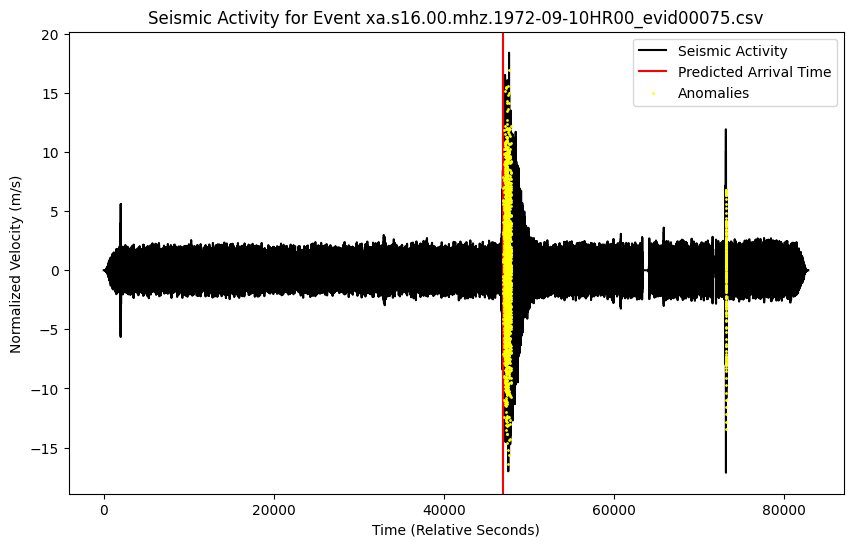

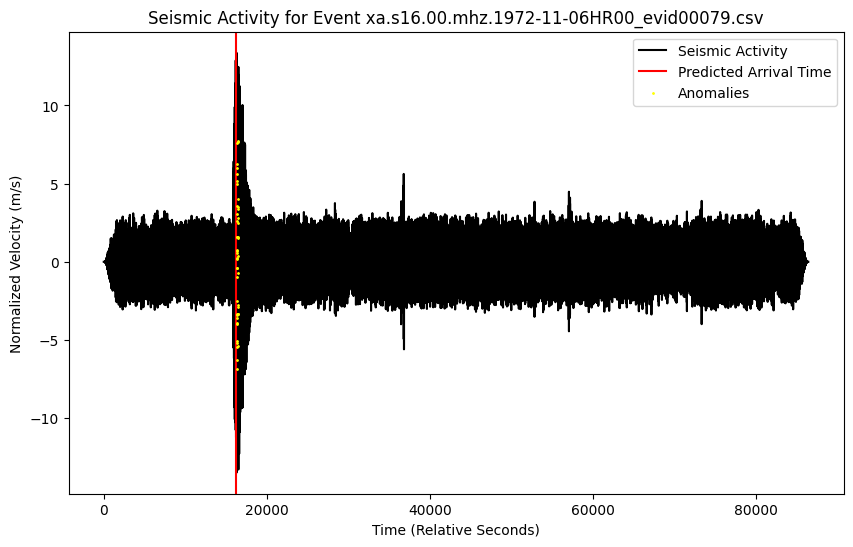

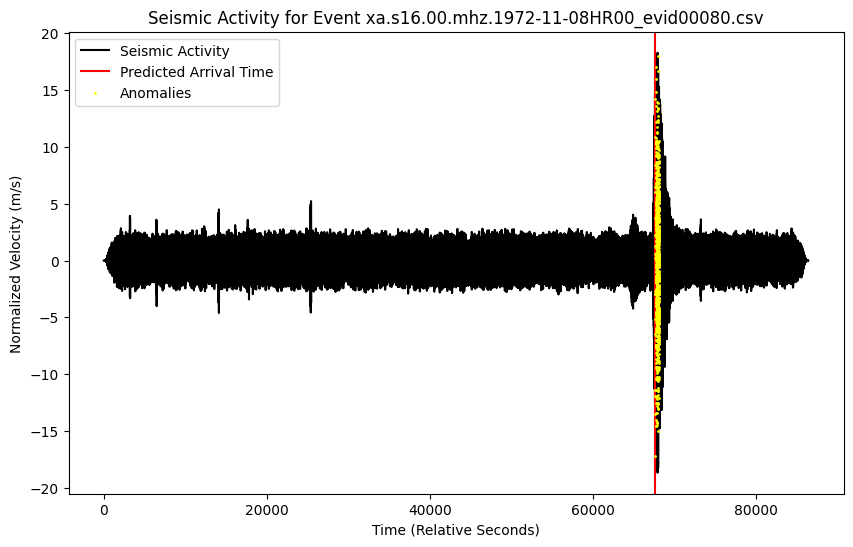

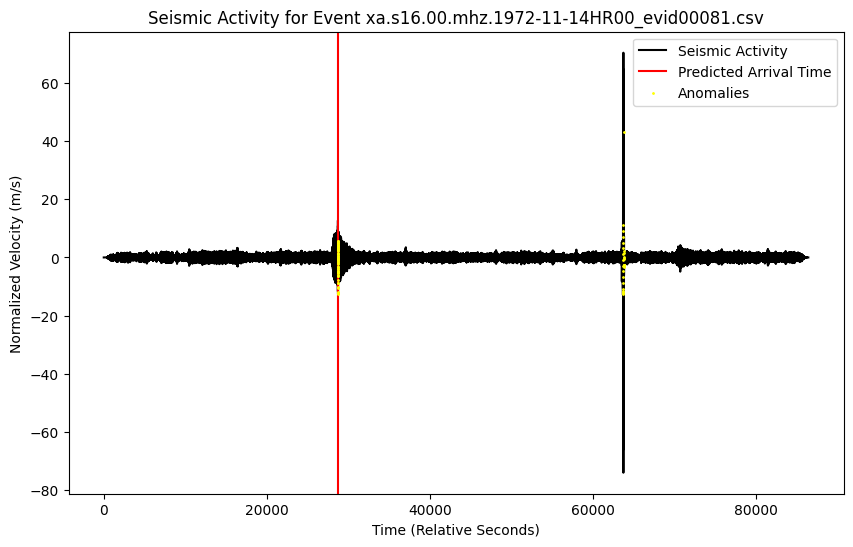

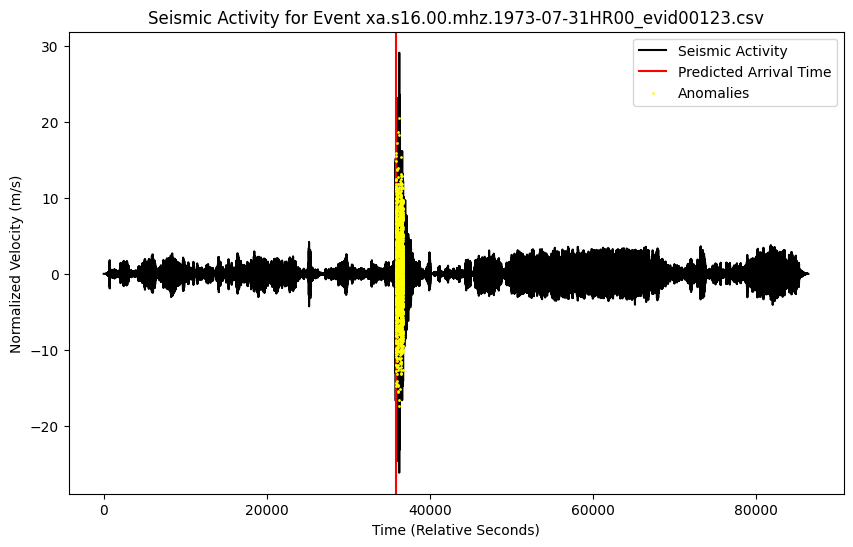

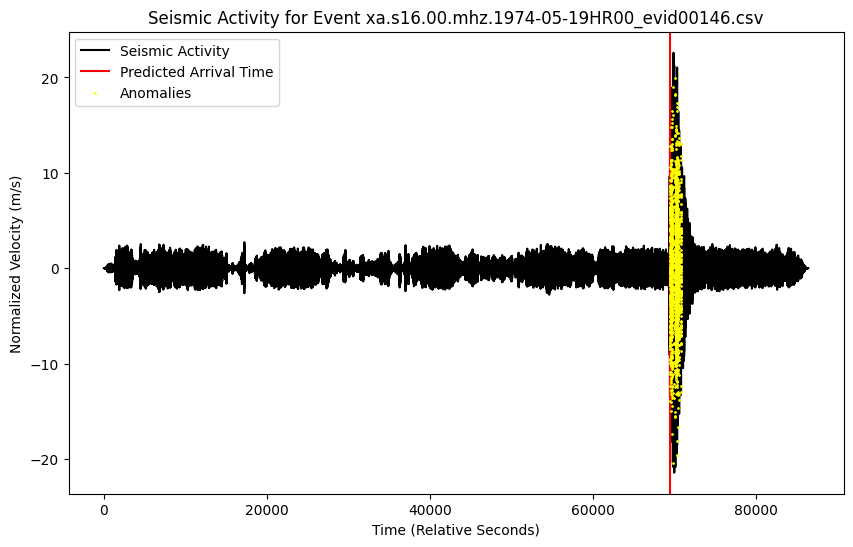

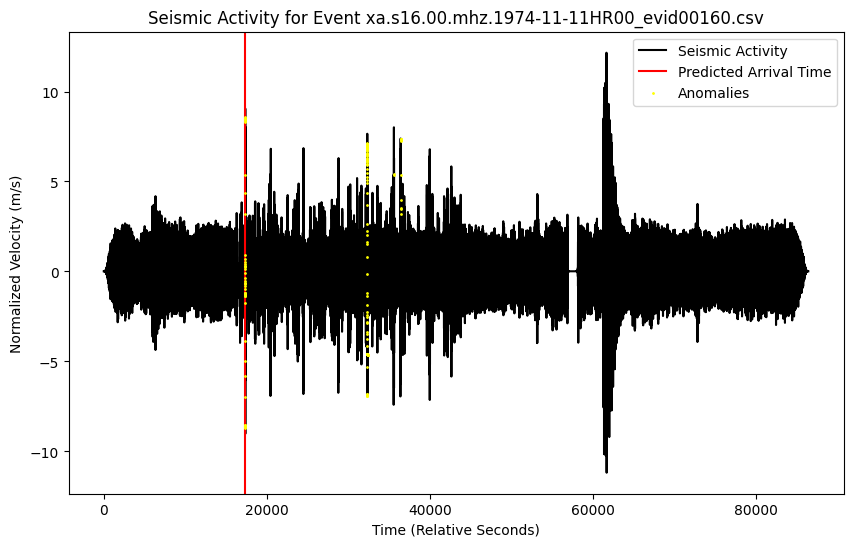

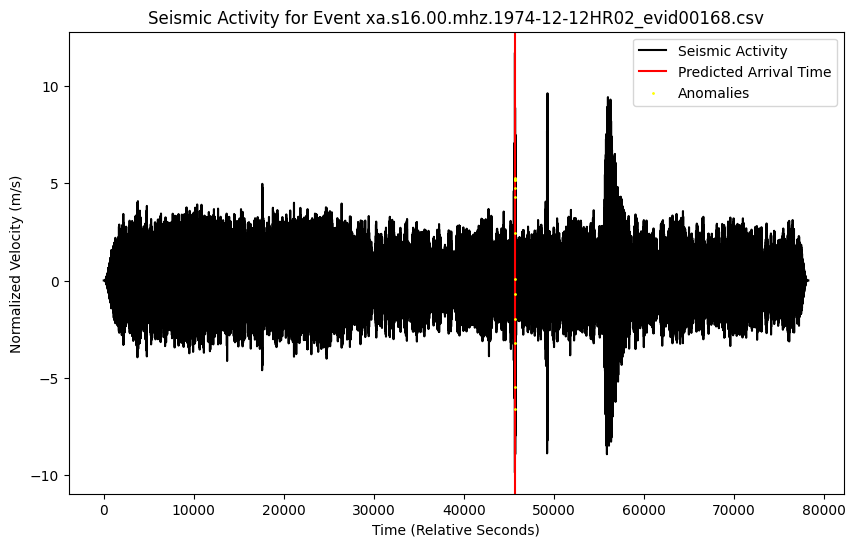

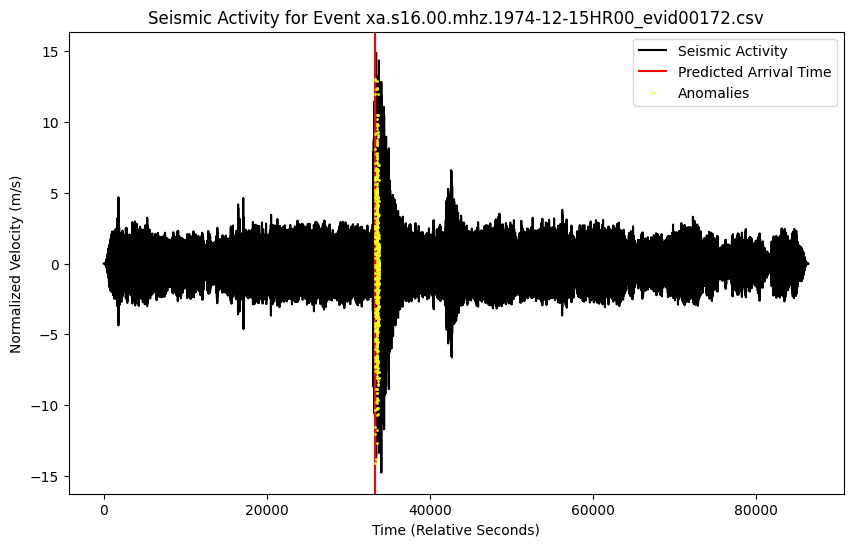

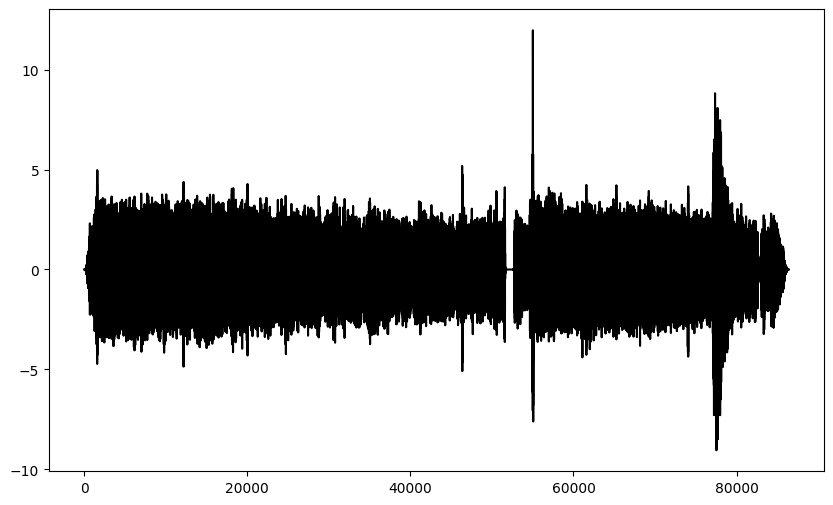

In [25]:
cumulative = 0
for i in event:
    length = lens_array[i]
    print(length)

    tiempo = time_arrays[i]
    X = data_arrays[i]
    plt.figure(figsize=(10, 6))
    plt.plot(
        tiempo,
        X,
        label="Seismic Activity",
        color="k",
    )

    anomaly_indices = np.where(anomalies_label)[0]
    print("Anomaly Indices:", anomaly_indices)

    anomaly_indices_in_event = np.array(
        [j for j in anomaly_indices if cumulative <= j and j <= cumulative + length]
    )
    print("Anomaly Indices in Event:", anomaly_indices_in_event)

    if train:
        true_arrival_line = plt.axvline(
            x=true_anomaly_time[i], c="green", label="True Arrival Time"
        )

    predicted_arrival_line_1 = plt.axvline(
        x=(anomaly_indices_in_event - cumulative)[0] / freq,
        c="red",
        label="Predicted Arrival Time",
    )

    plt.scatter(
        time_array[anomaly_indices_in_event + windows_size],
        data_array[anomaly_indices_in_event + windows_size],
        color="yellow",
        label="Anomalies",
        marker="o",
        s=1,
        zorder=2,
    )

    if moon:
        plt.title(f"Seismic Activity for Event {event_filename[i]}")
        plt.xlabel("Time (Relative Seconds)")
        plt.ylabel("Normalized Velocity (m/s)")
        plt.legend()
        if train:
            plt.savefig(f"../../predictions/fcnn/lunar/train/{event_filename[i]}.png")
        else:
            plt.savefig(
                f"../../predictions/fcnn/lunar/test/{test_set}/{event_filename[i]}_with_scatter.png"
            )
    else:
        plt.title(f"Seismic Activity for Event {event_filename[i]}")
        plt.xlabel("Time (Relative Seconds)")
        plt.ylabel("Normalized Velocity (c/s)")
        plt.legend()
        if train:
            plt.savefig(f"../../predictions/fcnn/mars/train/{event_filename[i]}.png")
        else:
            plt.savefig(
                f"../../predictions/fcnn/mars/test/{event_filename[i]}_with_scatter.png"
            )

    cumulative += length

## EXTRA: Confusion Matrix

Not really valid...


In [ ]:
conf_matrix = confusion_matrix(y, anomalies_label)

display = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix, display_labels=["Normal", "Anomaly"]
)

display.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Anomaly Detection")
plt.show()

# Extract Model


In [31]:
if train:
    if moon:
        model.save(
            f"../../trained_models/lunar/fcnn_moon__events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.keras"
        )
        model.save(
            f"../../trained_models/lunar/fcnn_moon__events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.h5"
        )
    else:
        model.save(
            f"../../trained_models/mars/fcnn_mars__events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.keras"
        )
        model.save(
            f"../../trained_models/mars/fcnn_mars__events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.h5"
        )

# Extract Data


In [78]:
if train:
    results_df = pd.DataFrame(
        {
            "true_labels": y,
            "predictions": reconstructed.flatten(),
            "mse": mse,
            "anomalies": anomalies_label,
        }
    )

    anomalies_df = pd.DataFrame(
        {"time_rel(sec)": time_array[windows_size:], "anomalies": anomalies_label}
    )
    if moon:
        results_df.to_csv(
            f"../../predictions/fcnn/lunar/train/seismicresults_events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.csv",
            index=False,
        )
        anomalies_df.to_csv(
            f"../../predictions/fcnn/lunar/train/seismicanomalies_events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.csv",
            index=False,
        )
    else:
        results_df.to_csv(
            f"../../predictions/fcnn/mars/train/seismicresults_events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.csv",
            index=False,
        )
        anomalies_df.to_csv(
            f"../../predictions/fcnn/mars/train/seismicanomalies_events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.csv",
            index=False,
        )

else:
    results_df = pd.DataFrame(
        {
            "predictions": reconstructed.flatten(),
            "mse": mse,
            "anomalies": anomalies_label,
        }
    )

    anomalies_df = pd.DataFrame(
        {"time_rel(sec)": time_array[windows_size:], "anomalies": anomalies_label}
    )
    if moon:
        results_df.to_csv(
            f"../../predictions/fcnn/lunar/test/{test_set}seismicresults_events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.csv",
            index=False,
        )
        anomalies_df.to_csv(
            f"../../predictions/fcnn/lunar/test/seismicanomalies_events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.csv",
            index=False,
        )
    else:
        results_df.to_csv(
            f"../../predictions/fcnn/mars/test/seismicresults_events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.csv",
            index=False,
        )
        anomalies_df.to_csv(
            f"../../predictions/fcnn/mars/test/seismicanomalies_events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.csv",
            index=False,
        )

## Load Saved Model


In [65]:
# train = False
# moon = False
# num_of_events = 2
# windows_size = 128
# batch_size = 256
# label_smoothing = 0.01
# n_epochs = 10

In [ ]:
# if not train:
#     if moon:
#         loaded_model = tf.keras.models.load_model(
#             f"../../trained_models/lunar/cnn_sigmoid_moon_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.keras"
#         )
#     else:
#         loaded_model = tf.keras.models.load_model(
#             f"../../trained_models/mars/cnn_sigmoid_mars_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.keras"
#         )

# loaded_model.summary()

In [ ]:
# loaded_model.evaluate(windows, y, verbose=2)

In [ ]:
# reconstructed = loaded_model.predict(windows)

In [ ]:
# print("Reconstructed Shape:", reconstructed.shape)
# print("Windows Shape:", windows.shape)

In [ ]:
# mse = np.mean(np.power(windows[:, :, 0] - reconstructed, 2), axis=1)
# print("MSE Shape:", mse.shape)

In [ ]:
# if moon:
#     high1 = np.quantile(np.abs(mse), 0.999)
#     # high2 = np.quantile(np.abs(mse), 0.9951)
#     anomalies_label = [1 if i > high1 else 0 for i in mse]
#     print("Predicted Anomaly Position:", np.argmax(anomalies_label))
#     print(
#         "Predicted Number of Anomalies:",
#         np.count_nonzero(anomalies_label),
#         "(depends directly on the quantile range)",
#     )
# else:
#     high1 = np.quantile(np.abs(mse), 0.9)
#     anomalies_label = [1 if i > high1 else 0 for i in mse]
#     print("Predicted Anomaly Position:", np.argmax(anomalies_label))
#     print(
#         "Predicted Number of Anomalies:",
#         np.count_nonzero(anomalies_label),
#         "(depends directly on the quantile range)",
#     )

In [ ]:
# cumulative = 0
# for i in event:
#     length = lens_array[i]
#     print(length)

#     tiempo = time_arrays[i]
#     X = data_arrays[i]
#     plt.figure(figsize=(10, 6))
#     plt.plot(
#         tiempo,
#         X,
#         label="Seismic Activity",
#         color="k",
#     )

#     anomaly_indices = np.where(anomalies_label)[0]
#     print("Anomaly Indices:", anomaly_indices)

#     anomaly_indices_in_event = np.array(
#         [j for j in anomaly_indices if cumulative <= j and j <= cumulative + length]
#     )
#     print("Anomaly Indices in Event:", anomaly_indices_in_event)

#     arrival_line = plt.axvline(
#         x=(anomaly_indices_in_event - cumulative)[0] / freq,
#         c="red",
#         label="Predicted Arrival Time",
#     )

#     plt.scatter(
#         time_array[anomaly_indices_in_event + windows_size],
#         data_array[anomaly_indices_in_event + windows_size],
#         color="yellow",
#         label="Anomalies",
#         marker="o",
#         s=1,
#         zorder=2,
#     )

#     if moon:
#         plt.title(f"Seismic Activity for Event {event_filename[i]}")
#         plt.xlabel("Time (Relative Seconds)")
#         plt.ylabel("Normalized Velocity (m/s)")
#         plt.legend()
#         plt.savefig(f"../../predictions/lunar/test/{event_filename[i]}.png")
#         # plt.savefig(f"../../predictions/lunar/test/{event_filename[i]}_with_scatter.png")
#     else:
#         plt.title(f"Seismic Activity for Event {event_filename[i]}")
#         plt.xlabel("Time (Relative Seconds)")
#         plt.ylabel("Normalized Velocity (c/s)")
#         plt.legend()
#         plt.savefig(f"../../predictions/mars/test/{event_filename[i]}.png")
#         # plt.savefig(f"../../predictions/mars/test/{event_filename[i]}_with_scatter)

#     cumulative += length